## Baseline-Modell

# Erstellt je User einen Case/Trace mit den dazugehörigen Events (Zustandsverläufen).
# Insgesamt 3 Zustände möglich.
Ob die Patienten Tinnitus hatten oder nicht, wird noch nicht beachtet.

In [1]:
import pandas as pd

In [2]:
# CSV laden
df = pd.read_csv('/Users/elias/Desktop/Uni/4. Semester : Masterarbeit/2026-04-02 TYT_answers2.csv', sep=";")

# Überblick verschaffen

In [3]:
df.head()

,id,q1,q2,q3,q4,q5,q6,q7,q8,soundlevel,...,notification_fixed,created_at,updated_at,date_of_birth2,age,famhistory,gender,handedness,onset_date2,onset_duration
0,2959,1.0,6.0,4.0,5.0,3.0,8.0,3.0,1.0,-688.462,...,0,22.04.14 13:58,22.04.14 13:58,14.02.79,35,0.0,0.0,0.0,14.02.10,4
1,2998,1.0,5.0,5.0,5.0,5.0,7.0,8.0,1.0,-109.410,...,0,27.04.14 08:10,27.04.14 08:10,14.02.79,35,0.0,0.0,0.0,14.02.10,4
2,3002,0.0,NaN,NaN,1.0,NaN,NaN,NaN,1.0,-120.225,...,0,28.04.14 15:45,28.04.14 15:45,14.02.79,35,0.0,0.0,0.0,14.02.10,4
3,3003,0.0,8.0,7.0,3.0,6.0,5.0,6.0,1.0,-394.602,...,0,28.04.14 15:45,28.04.14 15:45,14.02.79,35,0.0,0.0,0.0,14.02.10,4
4,3054,0.0,NaN,1.0,NaN,NaN,NaN,NaN,0.0,-187.568,...,0,22.05.14 12:58,22.05.14 12:58,14.02.79,35,0.0,0.0,0.0,14.02.10,4


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 112190 entries, 0 to 112189
Data columns (total 29 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  112190 non-null  int64  
 1   q1                  110565 non-null  float64
 2   q2                  110264 non-null  float64
 3   q3                  104169 non-null  float64
 4   q4                  109385 non-null  float64
 5   q5                  107775 non-null  float64
 6   q6                  103110 non-null  float64
 7   q7                  106857 non-null  float64
 8   q8                  108792 non-null  float64
 9   soundlevel          110045 non-null  float64
 10  sound_rounded       112190 non-null  int64  
 11  sound_env           110045 non-null  float64
 12  sound_env2          110045 non-null  str    
 13  user_id             112190 non-null  int64  
 14  user_os             112190 non-null  str    
 15  user_agent          112190 non-null  str    


In [5]:
df.describe(include="all")

,id,q1,q2,q3,q4,q5,q6,q7,q8,soundlevel,...,notification_fixed,created_at,updated_at,date_of_birth2,age,famhistory,gender,handedness,onset_date2,onset_duration
count,112190.000000,110565.000000,110264.000000,104169.000000,109385.000000,107775.000000,103110.000000,106857.000000,108792.000000,110045.000000,...,112190.000000,112190,112190,107193,110582,109714.000000,109641.000000,109756.000000,106169,110581
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,95272,95272,2880,84,NaN,NaN,NaN,1999,63
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,08.09.20 12:28,08.09.20 12:28,24.02.61,57,NaN,NaN,NaN,01.07.87,0
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,132,132,6815,7121,NaN,NaN,NaN,6817,20311
mean,60649.225689,0.800308,4.817883,3.754121,5.719943,2.546398,2.761643,5.929139,0.326982,701.249939,...,0.224610,NaN,NaN,NaN,NaN,0.206655,0.249368,0.370649,NaN,NaN
std,33379.682422,0.399771,3.137693,2.901579,2.199984,2.332471,2.445803,3.259860,0.469113,2517.894896,...,0.417327,NaN,NaN,NaN,NaN,0.404908,0.432649,0.686600,NaN,NaN
min,2959.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-998.378000,...,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN
25%,31524.250000,1.000000,2.000000,1.000000,5.000000,0.000000,1.000000,3.000000,0.000000,-355.795000,...,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN
50%,61250.500000,1.000000,4.000000,3.000000,5.000000,3.000000,2.000000,6.000000,0.000000,0.000000,...,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN
75%,89622.750000,1.000000,7.000000,6.000000,8.000000,4.000000,4.000000,9.000000,1.000000,436.000000,...,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,NaN


In [6]:
# Einzigartige Fälle
print("Anzahl Cases:", df["id"].nunique())

Anzahl Cases: 112184


In [7]:
# Einzigartige User
print("Anzahl User:", df["user_id"].nunique())

Anzahl User: 3339


In [8]:
# Einträge je User
print(f"Durchschnittliche Einträge pro User: {112184/3339:.2f}")

Durchschnittliche Einträge pro User: 33.60


In [9]:
# Fehlende Werte finden
df.isna().sum()

id                        0
q1                     1625
q2                     1926
q3                     8021
q4                     2805
q5                     4415
q6                     9080
q7                     5333
q8                     3398
soundlevel             2145
sound_rounded             0
sound_env              2145
sound_env2             2145
user_id                   0
user_os                   0
user_agent                0
save_date                 0
autosaved                 0
notification_date     92969
notification_fixed        0
created_at                0
updated_at                0
date_of_birth2         4997
age                    1608
famhistory             2476
gender                 2549
handedness             2434
onset_date2            6021
onset_duration         1609
dtype: int64

In [10]:
# IDs finden, bei denen age fehlt
users_with_missing_age = df[df["age"].isna()]["user_id"].unique()

print(f"Anzahl User mit fehlendem Age: {len(users_with_missing_age)}")
print("User IDs:", users_with_missing_age)

Anzahl User mit fehlendem Age: 43
User IDs: [  103   794   905  1708  1743  1747  1807  1828  1840  1884  1904  1907
  1911  1917  1918  1923  1932  1941  1954  1975  1984  2006  2017  2020
  2031  2050  2070  2117  2129  2238  2239  2259  2361  2414  2426  2463
  2471  2475  4941 28481 31298 34230 37214]


In [11]:
# IDs finden, bei denen gender fehlt
users_with_missing_gender = df[df["gender"].isna()]["user_id"].unique()

print(f"Anzahl User mit fehlendem Gender: {len(users_with_missing_gender)}")
print("User IDs:", users_with_missing_gender)

Anzahl User mit fehlendem Gender: 88
User IDs: [  103   410   536   554   569   570   573   580   582   583   584   585
   586   589   590   591   592   593   594   597   600   606   610   611
   613   614   615   619   620   622   623   625   771   794   905   978
  1161  1705  1708  1743  1747  1790  1807  1828  1838  1840  1884  1904
  1907  1911  1917  1918  1923  1932  1941  1945  1954  1975  1984  2006
  2017  2020  2031  2050  2070  2110  2117  2129  2238  2239  2259  2328
  2361  2364  2414  2426  2463  2471  2475  2928  3134  3591  3717  4941
 28481 31298 34230 37214]


In [12]:
# IDs finden, bei denen onset_duration fehlt
users_with_missing_onset_duration = df[df["onset_duration"].isna()]["user_id"].unique()

print(f"Anzahl User mit fehlendem onset_duration: {len(users_with_missing_onset_duration)}")
print("User IDs:", users_with_missing_onset_duration)

Anzahl User mit fehlendem onset_duration: 44
User IDs: [  103   325   794   905  1708  1743  1747  1807  1828  1840  1884  1904
  1907  1911  1917  1918  1923  1932  1941  1954  1975  1984  2006  2017
  2020  2031  2050  2070  2117  2129  2238  2239  2259  2361  2414  2426
  2463  2471  2475  4941 28481 31298 34230 37214]


# Aufräumen

In [13]:
# Schauen, ob zwei Spalten redundante Inhalte haben
# bei True sind die Inhalte 1:1 gleich
df["created_at"].equals(df["updated_at"])

True

In [14]:
# Schauen, ob die Infos in der Spalte überhaupt relevant sind
df["user_agent"]

0         TrackYourTinnitus/1.1.1 (iPhone; iOS 7.1; Scal...
1         TrackYourTinnitus/1.1.1 (iPhone; iOS 7.1.1; Sc...
2         TrackYourTinnitus/1.1.2 (iPhone; iOS 7.1.1; Sc...
3         TrackYourTinnitus/1.1.2 (iPhone; iOS 7.1.1; Sc...
4         TrackYourTinnitus/1.1.2 (iPhone; iOS 7.1.1; Sc...
                                ...                        
112185    TrackYourTinnitus/1.2.1.1 (iPhone; iOS 16.3.1;...
112186    TrackYourTinnitus/1.2.1.1 (iPhone; iOS 16.7.5;...
112187    TrackYourTinnitus/1.2.1.1 (iPhone; iOS 17.4.1;...
112188    TrackYourTinnitus/1.2.1.1 (iPhone; iOS 17.5.1;...
112189    TrackYourTinnitus/1.2.1.1 (iPhone; iOS 17.5.1;...
Name: user_agent, Length: 112190, dtype: str

In [15]:
# Schauen, ob die Infos in der Spalte überhaupt relevant sind
df["autosaved"]

0         1
1         0
2         1
3         0
4         1
         ..
112185    0
112186    0
112187    0
112188    0
112189    0
Name: autosaved, Length: 112190, dtype: int64

In [16]:
# Spalten "user_agent", "updated_at" und "autosaved" entfernen.
# zudem "notification_fixed" und "notification_date" entfernen, da Miriam sie für unwichtig erklärt hat
df = df.drop(columns=["user_agent", "updated_at", "autosaved", "notification_fixed", "notification_date"])

In [17]:
df.columns

Index(['id', 'q1', 'q2', 'q3', 'q4', 'q5', 'q6', 'q7', 'q8', 'soundlevel',
       'sound_rounded', 'sound_env', 'sound_env2', 'user_id', 'user_os',
       'save_date', 'created_at', 'date_of_birth2', 'age', 'famhistory',
       'gender', 'handedness', 'onset_date2', 'onset_duration'],
      dtype='str')

### Gemini test anfang

In [18]:
# Zeitspalten konvertieren
time_cols = ["save_date", "created_at"]

for col in time_cols:
    df[col] = pd.to_datetime(df[col], format="%d.%m.%y %H:%M", errors="coerce")

# 1. & 2. GENDER & GEWICHTUNG (Missing Values Check & Vorbereitung)
# Wir erstellen eine Flag für fehlende demografische Daten, um später deren Einfluss zu prüfen
df["missing_demographics"] = df["gender"].isna() | df["age"].isna()

# 3. Q1 (TINNITUS) BERÜCKSICHTIGEN
# Wir stellen sicher, dass q1 sauber ist. NaNs markieren wir als -1 (Unbekannt), um sie später als eigene Gruppe analysieren zu können.
# widerspricht sich mit den verschiedenen missing data Strategien.
df["q1"] = df["q1"].fillna(-1).astype(int)

# 4. SOUND_ENV NACH OS TRENNEN
# Wir erstellen zwei separate Spalten für die Sound-Umgebung,
# da die Skalen/Aufnahmen zwischen iOS und Android nicht direkt vergleichbar sind.
df["sound_env_ios"] = df.loc[df["user_os"] == "iOS", "sound_env"]
df["sound_env_android"] = df.loc[df["user_os"] == "android", "sound_env"]

# Alternative: Normalisierung (Z-Transformation) pro OS, falls du eine einzige Spalte brauchst
df["sound_env_norm"] = df.groupby("user_os")["sound_env"].transform(
    lambda x: (x - x.mean()) / x.std() if x.std() != 0 else 0
)

# 5. ZEITDIFFERENZ (CREATED_AT)
# Zuerst nach User und Zeit sortieren, dann Differenz zum vorherigen Event berechnen
df = df.sort_values(by=["user_id", "created_at"])
df["time_to_prev_event"] = df.groupby("user_id")["created_at"].diff().dt.days

In [19]:
print(df.groupby("user_os")["sound_env"].describe())

           count      mean       std           min       25%       50%  \
user_os                                                                  
Android  60377.0  0.047663  0.095966  0.000000e+00  0.000000  0.010071   
iOS      49668.0  0.015216  0.036126  1.000000e-08  0.001247  0.004612   

              75%       max  
user_os                      
Android  0.048128  0.980377  
iOS      0.013485  0.628887  


In [20]:
print(df["time_to_prev_event"].mean())

2.8359684339142497


### gemini test ende

In [21]:
# Schauen, dass Werte von Q1-Q8 im erlaubten Bereich sind
# q1 und q8 (0 oder 1)
invalid_q1_q8 = df[
    (df["q1"] < 0) | (df["q1"] > 1) |
    (df["q8"] < 0) | (df["q8"] > 1)
]
print("q1/q8 Fehler:", len(invalid_q1_q8))

# q2 bis q7 (0–10)
invalid_q2_q7 = df[
    (df[["q2","q3","q4","q5","q6","q7"]] < 0).any(axis=1) |
    (df[["q2","q3","q4","q5","q6","q7"]] > 10).any(axis=1)
]
print("q2–q7 Fehler:", len(invalid_q2_q7))

q1/q8 Fehler: 1625
q2–q7 Fehler: 0


In [22]:
# Schauen, dass "age" nicht <0 oder >110 ist
df["age"] = pd.to_numeric(df["age"], errors="coerce")
invalid_age = df[(df["age"] < 0) | (df["age"] > 110)]

print(invalid_age[["id", "user_id", "age"]])

          id  user_id    age
10948  12172      835  113.0


In [23]:
# Sicherstellen, dass "age" numerisch ist
df["age"] = pd.to_numeric(df["age"], errors="coerce")

# Alter und Onset_duration auf NaN setzen
df.loc[(df["user_id"] == 835) & ((df["age"] < 0) | (df["age"] > 110)), "age"] = pd.NA
df.loc[(df["user_id"] == 835), "onset_duration"] = pd.NA

# Kontrolle
df[df["user_id"] == 835]

,id,q1,q2,q3,q4,q5,q6,q7,q8,soundlevel,...,famhistory,gender,handedness,onset_date2,onset_duration,missing_demographics,sound_env_ios,sound_env_android,sound_env_norm,time_to_prev_event
10948,12172,1,9.0,10.0,0.0,0.0,9.0,5.0,1.0,909.0,...,0.0,0.0,2.0,12.03.02,NaN,False,NaN,NaN,-0.207597,NaN


In [24]:
df.isna().sum()

id                           0
q1                           0
q2                        1926
q3                        8021
q4                        2805
q5                        4415
q6                        9080
q7                        5333
q8                        3398
soundlevel                2145
sound_rounded                0
sound_env                 2145
sound_env2                2145
user_id                      0
user_os                      0
save_date                  612
created_at                   0
date_of_birth2            4997
age                       5611
famhistory                2476
gender                    2549
handedness                2434
onset_date2               6021
onset_duration            1610
missing_demographics         0
sound_env_ios            62522
sound_env_android       112190
sound_env_norm            2145
time_to_prev_event        3339
dtype: int64

## Missing Data Strategie fahren

In [25]:
# für uns wäre es meiner Meinung nach wichtig, Missing Data bei q1-q8 zu korrigieren.
# am wichtigsten ist eigentlich q1. Wenn's nicht ausgefüllt ist, dann ... machen.

'''
# einfach ignorieren und somit nichts machen
'''

'''
# Löschen von Zeilen mit fehlenden q1 Werten
df = df.dropna(subset=["q1"])
'''

'''
# Fehlende q1 Werte mit -1 ersetzen
df["q1"] = df["q1"].fillna(-1).astype(int)
'''

'''
# Fehlende q1 Werte mit dem Mittelwert ersetzen
import numpy as np
# Mittelwert berechnen und aufrunden
mean_val = df["q1"].mean()
rounded_val = int(np.ceil(mean_val)) # aus 0.80 wird 1
# Fehlende Werte ersetzen
df["q1"] = df["q1"].fillna(rounded_val)
print(f"Eingesetzter Mittelwert: {rounded_val}")
'''

'''
# Fehlende q1 Werte mit dem Median ersetzen
# Median berechnen
median_q1 = df["q1"].median()
# Fehlende Werte ersetzen
df["q1"] = df["q1"].fillna(median_q1)
print(f"Eingesetzter Median: {median_q1}")
'''

'''
# Fehlende q1 Werte mit kNN=5 ersetzen
from sklearn.impute import KNNImputer

# 1. Spalten auswählen, die für die Ähnlichkeit relevant sind
impute_cols = ["q1", "sound_env", "age", "gender"]

# Falls gender/sound_env Text sind, müssen sie in Zahlen umgewandelt werden (Faktorisiert)
df_impute = df[impute_cols].copy()

# Beispiel für kategorische Daten (falls nötig):
for col in df_impute.select_dtypes(include=['object']).columns:
    df_impute[col] = pd.factorize(df_impute[col])[0]

# 2. KNN Imputer konfigurieren (=5)
imputer = KNNImputer(n_neighbors=5)

# 3. Fehlende Werte schätzen
df_filled = imputer.fit_transform(df_impute)

# 4. Den Wert zurück in den originalen DataFrame schreiben
df["q1"] = df_filled[:, 0] # q1 ist die erste Spalte (Index 0)

# 5. Ergebnis auf 0 oder 1 runden
df["q1"] = df["q1"].round().astype(int)
'''

'\n# Fehlende q1 Werte mit kNN=5 ersetzen\nfrom sklearn.impute import KNNImputer\n\n# 1. Spalten auswählen, die für die Ähnlichkeit relevant sind\nimpute_cols = ["q1", "sound_env", "age", "gender"]\n\n# Falls gender/sound_env Text sind, müssen sie in Zahlen umgewandelt werden (Faktorisiert)\ndf_impute = df[impute_cols].copy()\n\n# Beispiel für kategorische Daten (falls nötig):\nfor col in df_impute.select_dtypes(include=[\'object\']).columns:\n    df_impute[col] = pd.factorize(df_impute[col])[0]\n\n# 2. KNN Imputer konfigurieren (=5)\nimputer = KNNImputer(n_neighbors=5)\n\n# 3. Fehlende Werte schätzen\ndf_filled = imputer.fit_transform(df_impute)\n\n# 4. Den Wert zurück in den originalen DataFrame schreiben\ndf["q1"] = df_filled[:, 0] # q1 ist die erste Spalte (Index 0)\n\n# 5. Ergebnis auf 0 oder 1 runden\ndf["q1"] = df["q1"].round().astype(int)\n'

In [26]:
# Kontrolle ob q1 noch fehlende Werte hat
df.isna().sum()

id                           0
q1                           0
q2                        1926
q3                        8021
q4                        2805
q5                        4415
q6                        9080
q7                        5333
q8                        3398
soundlevel                2145
sound_rounded                0
sound_env                 2145
sound_env2                2145
user_id                      0
user_os                      0
save_date                  612
created_at                   0
date_of_birth2            4997
age                       5611
famhistory                2476
gender                    2549
handedness                2434
onset_date2               6021
onset_duration            1610
missing_demographics         0
sound_env_ios            62522
sound_env_android       112190
sound_env_norm            2145
time_to_prev_event        3339
dtype: int64

## User mit nur einem Eintrag entfernen

In [27]:
'''
print(f"Anzahl einzigartiger Nutzer vor dem Entfernen: {df['user_id'].nunique()}")
# Behalte nur die user_id's, die mehr als einen Eintrag haben
df = df.groupby("user_id").filter(lambda x: len(x) > 1)

# Optional: Index zurücksetzen nach dem Löschen
#df = df.reset_index(drop=True)

# Kurze Kontrolle
print(f"Verbleibende Einträge: {len(df)}")
print(f"Anzahl einzigartiger Nutzer nach dem Entfernen: {df['user_id'].nunique()}")
print(f"Entfernte Nutzer: {3339-df['user_id'].nunique()}")
'''

'\nprint(f"Anzahl einzigartiger Nutzer vor dem Entfernen: {df[\'user_id\'].nunique()}")\n# Behalte nur die user_id\'s, die mehr als einen Eintrag haben\ndf = df.groupby("user_id").filter(lambda x: len(x) > 1)\n\n# Optional: Index zurücksetzen nach dem Löschen\n#df = df.reset_index(drop=True)\n\n# Kurze Kontrolle\nprint(f"Verbleibende Einträge: {len(df)}")\nprint(f"Anzahl einzigartiger Nutzer nach dem Entfernen: {df[\'user_id\'].nunique()}")\nprint(f"Entfernte Nutzer: {3339-df[\'user_id\'].nunique()}")\n'

# Daten aufbereiten

In [28]:
# Zeitspalten konvertieren
time_cols = ["save_date", "created_at"]

for col in time_cols:
    df[col] = pd.to_datetime(df[col], format="%d.%m.%y %H:%M", errors="coerce")

# Geburtsdatum
date_cols = ["date_of_birth2", "onset_date2"]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], format="%d.%m.%y", errors="coerce")

In [29]:
df[df["created_at"].isna()]

,id,q1,q2,q3,q4,q5,q6,q7,q8,soundlevel,...,famhistory,gender,handedness,onset_date2,onset_duration,missing_demographics,sound_env_ios,sound_env_android,sound_env_norm,time_to_prev_event


In [30]:
df[df["save_date"].isna()]

,id,q1,q2,q3,q4,q5,q6,q7,q8,soundlevel,...,famhistory,gender,handedness,onset_date2,onset_duration,missing_demographics,sound_env_ios,sound_env_android,sound_env_norm,time_to_prev_event
2633,3189,0,8.0,4.0,4.0,5.0,2.0,9.0,1.0,NaN,...,0.0,0.0,1.0,NaT,#WERT!,False,NaN,NaN,NaN,NaN
2634,3190,1,7.0,5.0,NaN,NaN,NaN,NaN,0.0,-425.513,...,0.0,0.0,1.0,NaT,#WERT!,False,0.007455,NaN,-0.214843,0.0
2635,3191,1,6.0,4.0,4.0,NaN,NaN,NaN,0.0,NaN,...,0.0,0.0,1.0,NaT,#WERT!,False,NaN,NaN,NaN,0.0
2636,3192,1,5.0,2.0,4.0,5.0,2.0,7.0,1.0,-350.426,...,0.0,0.0,1.0,NaT,#WERT!,False,0.017696,NaN,0.068641,0.0
2637,3193,1,6.0,5.0,4.0,NaN,NaN,NaN,0.0,-539.439,...,1.0,0.0,0.0,1995-03-07,#WERT!,False,0.002008,NaN,-0.365611,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110295,110864,1,6.0,5.0,0.0,6.0,2.0,1.0,0.0,-522.364,...,0.0,1.0,2.0,2009-01-06,#WERT!,False,0.002444,NaN,-0.353535,0.0
110296,110865,1,6.0,5.0,0.0,6.0,2.0,1.0,0.0,-522.364,...,0.0,1.0,2.0,2009-01-06,#WERT!,False,0.002444,NaN,-0.353535,0.0
110297,110866,1,6.0,5.0,0.0,6.0,2.0,1.0,0.0,-522.364,...,0.0,1.0,2.0,2009-01-06,#WERT!,False,0.002444,NaN,-0.353535,0.0
110298,110867,1,6.0,5.0,0.0,6.0,2.0,1.0,0.0,-522.364,...,0.0,1.0,2.0,2009-01-06,#WERT!,False,0.002444,NaN,-0.353535,0.0


In [31]:
# Spalte "save_date" entfernen. Wir werden "created_at" als Zeitstempel nehmen
df = df.drop(columns=["save_date"])

In [32]:
# Änderungen kontrollieren
df.head()

,id,q1,q2,q3,q4,q5,q6,q7,q8,soundlevel,...,famhistory,gender,handedness,onset_date2,onset_duration,missing_demographics,sound_env_ios,sound_env_android,sound_env_norm,time_to_prev_event
0,2959,1,6.0,4.0,5.0,3.0,8.0,3.0,1.0,-688.462,...,0.0,0.0,0.0,2010-02-14,4,False,0.000361,NaN,-0.411203,NaN
1,2998,1,5.0,5.0,5.0,5.0,7.0,8.0,1.0,-109.410,...,0.0,0.0,0.0,2010-02-14,4,False,0.000003,NaN,-0.421107,4.0
2,3002,0,NaN,NaN,1.0,NaN,NaN,NaN,1.0,-120.225,...,0.0,0.0,0.0,2010-02-14,4,False,0.250539,NaN,6.514017,1.0
3,3003,0,8.0,7.0,3.0,6.0,5.0,6.0,1.0,-394.602,...,0.0,0.0,0.0,2010-02-14,4,False,0.010641,NaN,-0.126639,0.0
4,3054,0,NaN,1.0,NaN,NaN,NaN,NaN,0.0,-187.568,...,0.0,0.0,0.0,2010-02-14,4,False,0.115388,NaN,2.772874,23.0


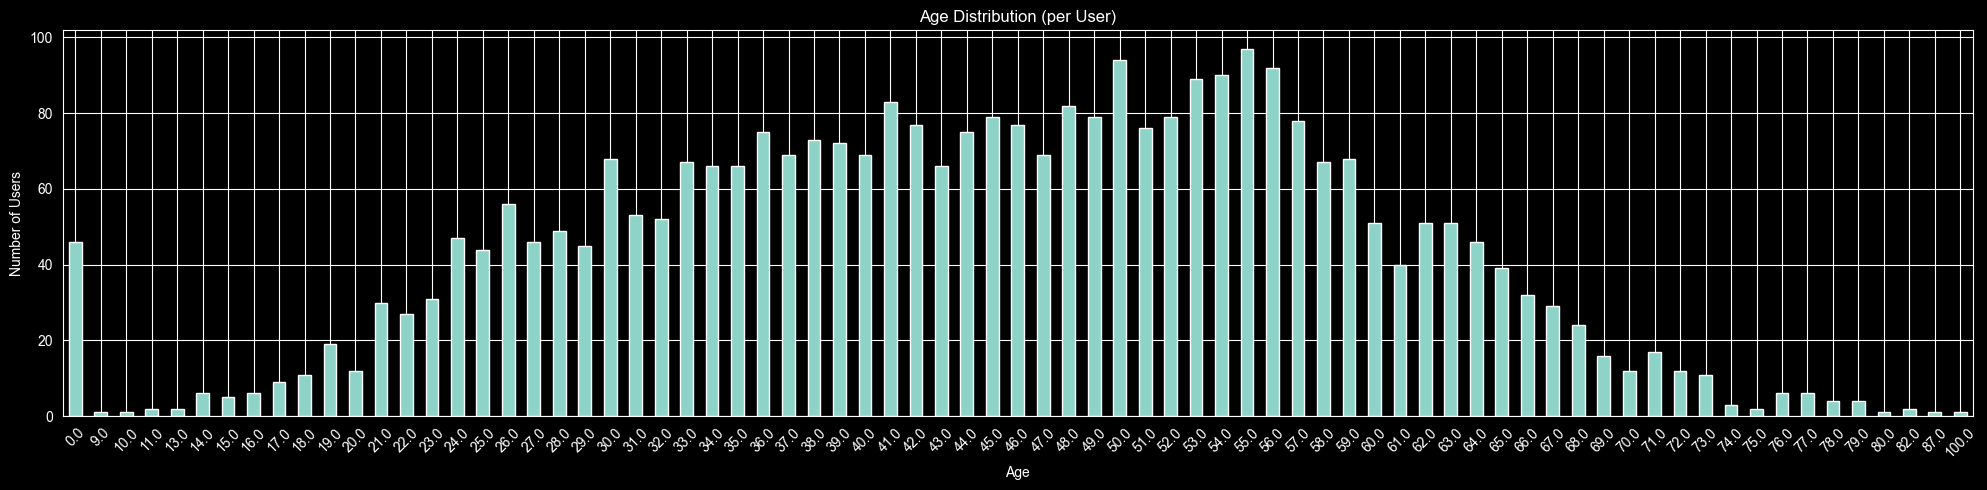

In [33]:
import matplotlib.pyplot as plt

# pro User genau ein Eintrag (z. B. erster Eintrag)
df_user = df.drop_duplicates(subset="user_id")

plt.figure(figsize=(20,5))

df_user["age"].value_counts().sort_index().plot(kind="bar")

plt.title("Age Distribution (per User)")
plt.xlabel("Age")
plt.ylabel("Number of Users")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Vorbereitung des Dataframes auf die PM4Py Analyse

In [34]:
# Score berechnen (ohne q1 und q8)
df["score"] = df[["q2","q3","q4","q5","q6","q7"]].sum(axis=1)

# Kategorien definieren
def categorize(score):
    if score <= 20:
        return "low"
    elif score <= 40:
        return "medium"
    else:
        return "high"

df["concept:name"] = df["score"].apply(categorize)

In [35]:
# Case = Patient
df_event = df.rename(columns={
    "user_id": "case:concept:name",
    "created_at": "time:timestamp"
})

# Datentypen fixen
df_event["case:concept:name"] = df_event["case:concept:name"].astype(str)
df_event["concept:name"] = df_event["concept:name"].astype(str)

# Datentypen Kontrollieren
print(df_event["case:concept:name"].dtype)
print(df_event["concept:name"].dtype)

# Sortieren nach Zeit
df_event = df_event.sort_values(
    by=["case:concept:name", "time:timestamp"]
)

# Relevante Spalten behalten
df_event = df_event[[
    "case:concept:name",
    "concept:name",
    "time:timestamp",
    "age",
    "gender",
    "sound_env"
]]

df_event

str
str


,case:concept:name,concept:name,time:timestamp,age,gender,sound_env
13122,1000,medium,2015-04-14 13:43:00,38.0,0.0,0.000610
13123,1000,medium,2015-04-14 21:16:00,38.0,0.0,0.001312
13124,1000,medium,2015-04-15 09:39:00,38.0,0.0,0.002045
13125,1000,low,2015-04-15 13:16:00,38.0,0.0,0.001221
13126,1000,low,2015-04-20 21:09:00,38.0,0.0,0.000427
...,...,...,...,...,...,...
13117,997,medium,2015-04-09 07:17:00,30.0,0.0,0.000655
13118,997,low,2015-04-09 16:48:00,30.0,0.0,0.007934
13119,997,medium,2015-04-09 16:48:00,30.0,0.0,0.004330
13120,998,medium,2015-04-14 19:53:00,65.0,0.0,0.001740


In [36]:
# Personen je Level
df_event.groupby("concept:name")["case:concept:name"].nunique()

concept:name
high       466
low       1766
medium    2932
Name: case:concept:name, dtype: int64

In [37]:
# Traces je Level
df_event.groupby("concept:name")["concept:name"].count()

concept:name
high       3584
low       34995
medium    73611
Name: concept:name, dtype: int64

In [38]:
# Personen, die nur einen Eintrag geleistet haben
(df_event["case:concept:name"].value_counts() == 1).sum()

np.int64(1018)

In [39]:
# Personen, die nur einen Eintrag geleistet haben in %
(1018/3339)*100

30.48817011081162

In [40]:
# oder das
# hier viel weniger Attribute mitgenommen
'''
question_cols = ["q1","q2","q3","q4","q5","q6","q7","q8"]

df_event = df.melt(
id_vars=["id", "created_at"],
value_vars=question_cols,
var_name="concept:name",
value_name="value"
)

# Spalten für PM4Py umbenennen
df_event = df_event.rename(columns={
"id": "case:concept:name",
"created_at": "time:timestamp"
})

df_event.head()
'''

'\nquestion_cols = ["q1","q2","q3","q4","q5","q6","q7","q8"]\n\ndf_event = df.melt(\nid_vars=["id", "created_at"],\nvalue_vars=question_cols,\nvar_name="concept:name",\nvalue_name="value"\n)\n\n# Spalten für PM4Py umbenennen\ndf_event = df_event.rename(columns={\n"id": "case:concept:name",\n"created_at": "time:timestamp"\n})\n\ndf_event.head()\n'

In [41]:
df_event[df_event["time:timestamp"].isna()]

,case:concept:name,concept:name,time:timestamp,age,gender,sound_env


In [42]:
# Kontrollieren, dass jetzt die Sortierung nach Case und timestamp sortiert ist
df_event.head(20)

,case:concept:name,concept:name,time:timestamp,age,gender,sound_env
13122,1000,medium,2015-04-14 13:43:00,38.0,0.0,0.000610
13123,1000,medium,2015-04-14 21:16:00,38.0,0.0,0.001312
13124,1000,medium,2015-04-15 09:39:00,38.0,0.0,0.002045
13125,1000,low,2015-04-15 13:16:00,38.0,0.0,0.001221
13126,1000,low,2015-04-20 21:09:00,38.0,0.0,0.000427
13127,1000,medium,2015-04-25 22:19:00,38.0,0.0,0.000824
13128,1000,low,2015-05-06 11:54:00,38.0,0.0,0.001282
13129,1000,low,2015-07-14 12:00:00,39.0,0.0,0.176550
13130,1000,low,2015-07-14 12:00:00,39.0,0.0,0.003113
13131,1000,low,2015-12-15 19:45:00,39.0,0.0,0.001862


In [43]:
import pm4py
from pm4py.algo.filtering.log.variants import variants_filter

log = pm4py.convert_to_event_log(df_event)
print("Anzahl Traces:", len(log))

# Die Varianten (Traces) zählen
variants = pm4py.get_variants(log)

# Sortieren und die Top 100/x/1000 holen
filtered_log = pm4py.filter_variants_top_k(log, k=250)


Anzahl Traces: 3339


In [44]:
# euren gewünschten Pfad hernehmen. Dann auch hernehmen, um damit weiter zu arbeiten.

pm4py.write_xes(log, '/Users/elias/Desktop/Uni/4. Semester : Masterarbeit/2026-04-06 TYT_event_log V2.0.xes')
pm4py.write_xes(filtered_log, '/Users/elias/Desktop/Uni/4. Semester : Masterarbeit/2026-04-06 TYT_event_log V2.0 filtered.xes')

/Users/elias/PycharmProjects/MasterArbeit/.venv/lib/python3.12/site-packages/pm4py/utils.py:1025: UserWarning: Install the optional requirement `r4pm` to import/export files faster. `rustxes` remains supported as a fallback.
  warnings.warn(
/Users/elias/PycharmProjects/MasterArbeit/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
exporting log, completed traces :: 100%|██████████| 2350/2350 [00:00<00:00, 6861.41it/s] 


# gemini beginn

In [45]:
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import pandas as pd

# --- A. DATENBEREINIGUNG (Fix für #ZAHL!) ---
# Alle nicht-numerischen Werte in onset_duration zu NaN machen
df["onset_duration"] = pd.to_numeric(df["onset_duration"], errors="coerce")

# Nur relevante Spalten für die Analyse auswählen
features = [
    "age", "q1", "time_to_prev_event",
    "sound_env_norm", "missing_demographics", "onset_duration"
]

# Zielvariable (der aktuelle Score)
target = "score"

# Daten bereinigen: Nur Zeilen ohne NaNs in diesen Spalten nutzen
analysis_df = df[features + [target]].dropna()

# Falls user_OS noch ein String ist, für die Analyse in Zahlen umwandeln
# analysis_df["user_OS_coded"] = pd.factorize(df["user_OS"])[0]

In [46]:
df.info()

<class 'pandas.DataFrame'>
Index: 112190 entries, 0 to 112189
Data columns (total 30 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   id                    112190 non-null  int64         
 1   q1                    112190 non-null  int64         
 2   q2                    110264 non-null  float64       
 3   q3                    104169 non-null  float64       
 4   q4                    109385 non-null  float64       
 5   q5                    107775 non-null  float64       
 6   q6                    103110 non-null  float64       
 7   q7                    106857 non-null  float64       
 8   q8                    108792 non-null  float64       
 9   soundlevel            110045 non-null  float64       
 10  sound_rounded         112190 non-null  int64         
 11  sound_env             110045 non-null  float64       
 12  sound_env2            110045 non-null  str           
 13  user_id        

In [47]:
analysis_df
analysis_df.info()

<class 'pandas.DataFrame'>
Index: 100391 entries, 1 to 112189
Data columns (total 7 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   age                   100391 non-null  float64
 1   q1                    100391 non-null  int64  
 2   time_to_prev_event    100391 non-null  float64
 3   sound_env_norm        100391 non-null  float64
 4   missing_demographics  100391 non-null  bool   
 5   onset_duration        100391 non-null  float64
 6   score                 100391 non-null  float64
dtypes: bool(1), float64(5), int64(1)
memory usage: 5.5 MB


In [48]:
# Modell definieren
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Training
X = analysis_df[features]
y = analysis_df[target]
model.fit(X, y)

# Gewichte extrahieren
importances = pd.DataFrame({
    "Feature": features,
    "Gewichtung": model.feature_importances_
}).sort_values(by="Gewichtung", ascending=False)

print("\n--- Statistische Gewichtung der Features ---")
print(importances)


--- Statistische Gewichtung der Features ---
                Feature  Gewichtung
3        sound_env_norm    0.353972
0                   age    0.265797
5        onset_duration    0.236750
1                    q1    0.091834
2    time_to_prev_event    0.051369
4  missing_demographics    0.000278


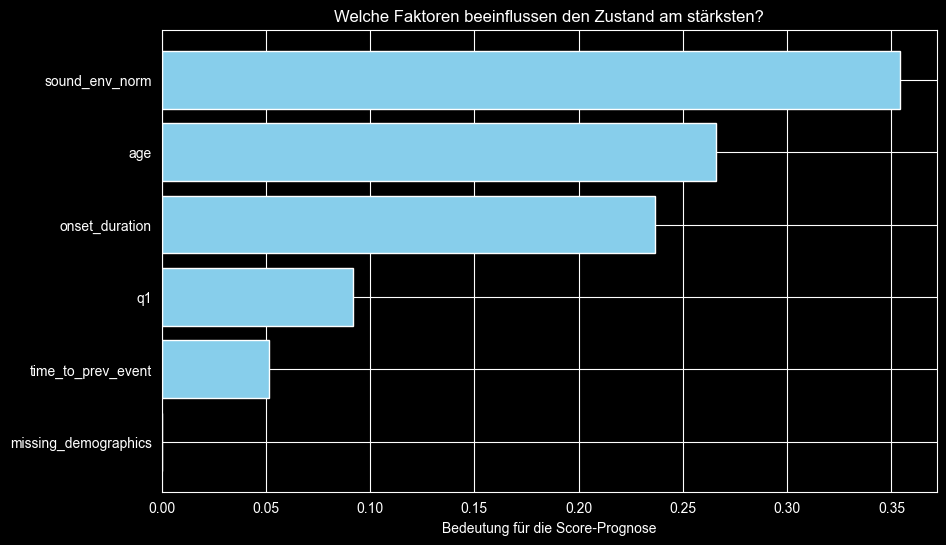

In [49]:
plt.figure(figsize=(10, 6))
plt.barh(importances["Feature"], importances["Gewichtung"], color="skyblue")
plt.xlabel("Bedeutung für die Score-Prognose")
plt.title("Welche Faktoren beeinflussen den Zustand am stärksten?")
plt.gca().invert_yaxis()
plt.show()

In [50]:
# Prüfe die Korrelation zwischen Sound und Score im Detail
print(f"Korrelation Sound/Score: {analysis_df['sound_env_norm'].corr(analysis_df['score']):.3f}")

# Schau dir den durchschnittlichen Score in Sound-Quantilen an
analysis_df['sound_bins'] = pd.qcut(analysis_df['sound_env_norm'], q=5)
print(analysis_df.groupby('sound_bins')[target].mean())

Korrelation Sound/Score: 0.043
sound_bins
(-0.498, -0.469]    22.947536
(-0.469, -0.385]    24.568984
(-0.385, -0.253]    24.736944
(-0.253, 0.138]     24.922966
(0.138, 16.987]     24.989391
Name: score, dtype: float64


--- Schwellenwert Analyse: Sound vs. Score ---
         sound_bins      score
0   (-0.498, -0.46]  23.265778
1   (-0.46, -0.421]  24.161669
2  (-0.421, -0.383]  24.806210
3  (-0.383, -0.333]  24.728824
4  (-0.333, -0.256]  24.752068
5  (-0.256, -0.126]  25.026177
6   (-0.126, 0.117]  25.018822
7     (0.117, 0.76]  24.813341
8    (0.76, 16.987]  25.334666


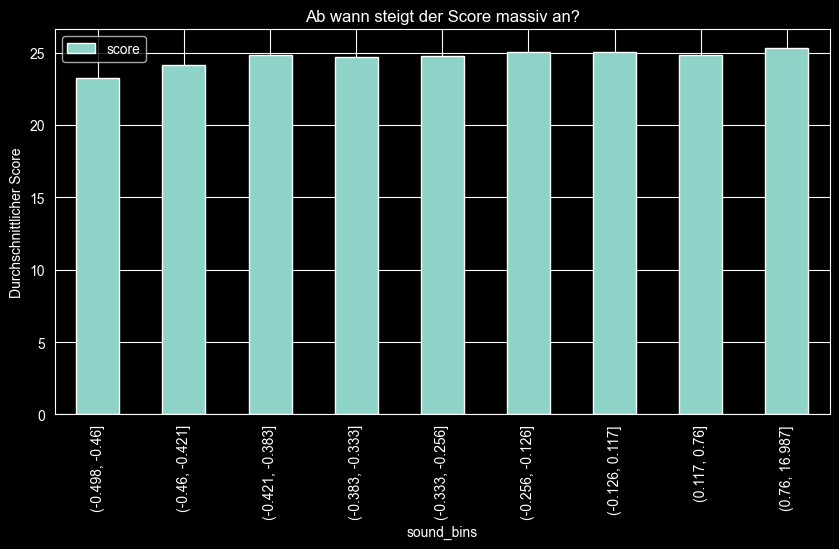

In [51]:
# Sound-Daten in 10 gleich große Gruppen unterteilen (Dezile)
df['sound_bins'] = pd.qcut(df['sound_env_norm'], q=10, duplicates='drop')

# Durchschnittlichen Score pro Gruppe berechnen
threshold_analysis = df.groupby('sound_bins', observed=True)['score'].mean().reset_index()

print("--- Schwellenwert Analyse: Sound vs. Score ---")
print(threshold_analysis)

# Visualisierung
import matplotlib.pyplot as plt
threshold_analysis.plot(kind='bar', x='sound_bins', y='score', figsize=(10,5))
plt.title("Ab wann steigt der Score massiv an?")
plt.ylabel("Durchschnittlicher Score")
plt.show()

In [52]:
# 1. Veränderungen berechnen (Delta)
df = df.sort_values(by=["user_id", "created_at"])
df['delta_sound'] = df.groupby('user_id')['sound_env_norm'].diff()
df['delta_score'] = df.groupby('user_id')['score'].diff()

# 2. Den nächsten Score-Schritt an die aktuelle Zeile ziehen (Shift -1)
# Wir wollen wissen: Wenn Sound JETZT steigt, was macht der Score beim NÄCHSTEN Mal?
df['next_delta_score'] = df.groupby('user_id')['delta_score'].shift(-1)

# 3. Zeitabstand zum nächsten Event berechnen
df['days_to_next'] = df.groupby('user_id')['time_to_prev_event'].shift(-1)

# 4. Filter: Nur Fälle, in denen sich der Sound signifikant verschlechtert hat (z.B. Delta > 0.5. Kann aber auch 0.3 oder 0.7 sein)
deterioration = df[df['delta_sound'] > 0.5].copy()

print("--- Analyse bei Sound-Verschlechterung ---")
print(f"Durchschnittliche Score-Änderung beim nächsten Termin: {deterioration['next_delta_score'].mean():.2f}")
print(f"Mittlerer Zeitabstand bis zur Score-Reaktion (Tage): {deterioration['days_to_next'].mean():.1f}")

--- Analyse bei Sound-Verschlechterung ---
Durchschnittliche Score-Änderung beim nächsten Termin: 0.28
Mittlerer Zeitabstand bis zur Score-Reaktion (Tage): 2.6


In [53]:
print(f"Anzahl der untersuchten Verschlechterungs-Ereignisse: {len(deterioration)}")

Anzahl der untersuchten Verschlechterungs-Ereignisse: 11370


In [54]:
# Prüfen, wie oft ein Sound-Delta (>0.5) zu einem Zustandswechsel führt
df['next_concept'] = df.groupby('user_id')['concept:name'].shift(-1)
df['state_changed'] = df['concept:name'] != df['next_concept']

# Filter auf Verschlechterung
det_change = df[df['delta_sound'] > 0.5]

change_rate = det_change['state_changed'].mean() * 100
print(f"Wahrscheinlichkeit eines Zustandswechsels nach Lärm: {change_rate:.2f}%")

Wahrscheinlichkeit eines Zustandswechsels nach Lärm: 23.13%


In [55]:
import pm4py
from pm4py.objects.conversion.log import converter as log_converter

# Flag setzen: War das vorherige Event eine Sound-Verschlechterung?
df['after_noise_burst'] = df.groupby('user_id')['delta_sound'].shift(1) > 0.5
df['after_noise_burst'] = df['after_noise_burst'].fillna(False)

# Wir erstellen zwei Dataframes für den Vergleich
df_noise = df[df['after_noise_burst'] == True].copy()
df_stable = df[df['after_noise_burst'] == False].copy()

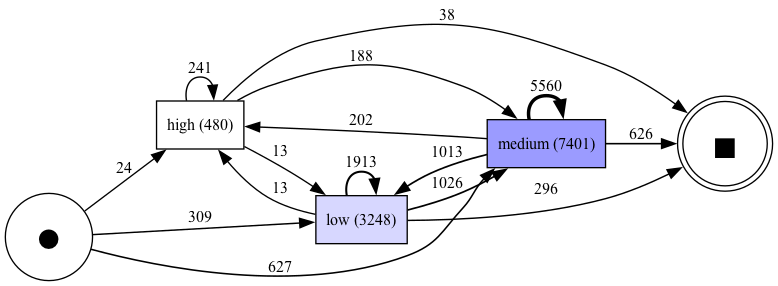

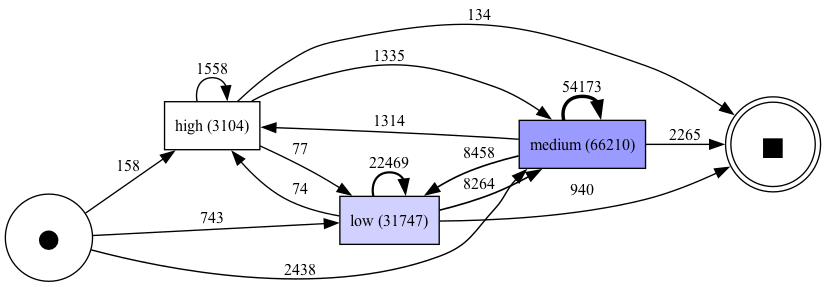

In [56]:
def get_dfg(dataframe):
    log_df = dataframe.copy()
    log_df = log_df.rename(columns={
        "user_id": "case:concept:name",
        "concept:name": "concept:name",
        "created_at": "time:timestamp"
    })
    log_df["case:concept:name"] = log_df["case:concept:name"].astype(str)
    # Wichtig: Du musst den Zeitstempel nochmal sicherstellen
    log_df["time:timestamp"] = pd.to_datetime(log_df["time:timestamp"])
    return log_df # Das hat gefehlt!

# Dann erst die Logs bauen
log_noise = get_dfg(df_noise)
log_stable = get_dfg(df_stable)

# discover_dfg gibt drei Werte zurück: dfg, start_activities, end_activities
dfg_n, start_n, end_n = pm4py.discover_dfg(log_noise)

# 15. DFG visualisieren mit expliziter Übergabe der Start- und Endpunkte
pm4py.view_dfg(dfg_n, start_n, end_n)

# 16. Das Gleiche für die stabile Gruppe zum Vergleich
dfg_s, start_s, end_s = pm4py.discover_dfg(log_stable)
pm4py.view_dfg(dfg_s, start_s, end_s)

In [57]:
def calculate_transition_probs(df_log, label):
    # DFG entdecken (Häufigkeiten)
    dfg, start_act, end_act = pm4py.discover_dfg(df_log)

    # Ein Dictionary bauen, um die Summen pro Ausgangszustand zu halten
    totals = {}
    for (source, target), count in dfg.items():
        totals[source] = totals.get(source, 0) + count

    # Wahrscheinlichkeiten berechnen
    probs = []
    for (source, target), count in dfg.items():
        percentage = (count / totals[source]) * 100
        probs.append({
            "Von": source,
            "Nach": target,
            "Wahrscheinlichkeit": round(percentage, 2),
            "Gruppe": label
        })

    return pd.DataFrame(probs)

# Matrizen für beide Gruppen berechnen
matrix_noise = calculate_transition_probs(log_noise, "Lärm-Exponiert")
matrix_stable = calculate_transition_probs(log_stable, "Stabil")

# Zusammenführen für den direkten Vergleich
comparison_df = pd.concat([matrix_noise, matrix_stable])

# Pivot-Tabelle für bessere Lesbarkeit
pivot_comparison = comparison_df.pivot(index=["Von", "Nach"], columns="Gruppe", values="Wahrscheinlichkeit")
print("--- Vergleich der Übergangswahrscheinlichkeiten (%) ---")
print(pivot_comparison)

--- Vergleich der Übergangswahrscheinlichkeiten (%) ---
Gruppe         Lärm-Exponiert  Stabil
Von    Nach                          
high   high             54.52   52.46
       low               2.94    2.59
       medium           42.53   44.95
low    high              0.44    0.24
       low              64.80   72.93
       medium           34.76   26.83
medium high              2.98    2.05
       low              14.95   13.23
       medium           82.07   84.72


In [59]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
from sklearn.ensemble import RandomForestRegressor

# --- C. SIGNIFIKANZ-TEST (Chi-Quadrat) ---
# Wir prüfen: Ist der Wechsel von LOW zu MEDIUM abhängig vom Lärm?
# Erstellung einer Kontingenztabelle (Häufigkeitstabelle)
contingency_table = pd.crosstab(df['after_noise_burst'], df['next_concept'])

# Nur relevante Zustände vergleichen (z.B. Wechsel nach Medium)
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("\n--- Signifikanz-Analyse ---")
print(f"Chi-Quadrat: {chi2:.2f}")  #Je größer dieser Wert ist, desto stärker ist der Hinweis, dass Lärm und der nächste Score-Zustand tatsächlich zusammenhängen.
print(f"p-Wert: {p_value:.4f}")  #p<0.05: Das Ergebnis gilt als signifikant. Du kannst mit 95%iger Sicherheit sagen: Der Lärm hat einen Einfluss.

if p_value < 0.05:
    print("Ergebnis: Statistisch signifikant (#Der Effekt ist kein Zufall).")
else:
    print("Ergebnis: Nicht signifikant.")


--- Signifikanz-Analyse ---
Chi-Quadrat: 58.32
p-Wert: 0.0000
Ergebnis: Statistisch signifikant (#Der Effekt ist kein Zufall).


In [60]:
# schauen, ob 'frische' vs. 'chronische' Patienten einen Score Anstieg durch Lärm erfahren.
# 1. Median der Onset-Dauer finden
onset_median = df['onset_duration'].median()

# 2. Zwei Sub-Logs erstellen (PM4Py-Format)
log_fresh = get_dfg(df[df['onset_duration'] <= onset_median])
log_chronic = get_dfg(df[df['onset_duration'] > onset_median])

# 3. Den Lärm-Effekt innerhalb dieser Gruppen vergleichen
# (Wir schauen nur auf die Zeilen nach einem Noise-Burst)
fresh_noise_effect = df[(df['onset_duration'] <= onset_median) & (df['after_noise_burst'] == True)]['next_delta_score'].mean()
chronic_noise_effect = df[(df['onset_duration'] > onset_median) & (df['after_noise_burst'] == True)]['next_delta_score'].mean()

print(f"Score-Anstieg nach Lärm bei 'frischen' Fällen: {fresh_noise_effect:.4f}")
print(f"Score-Anstieg nach Lärm bei 'chronischen' Fällen: {chronic_noise_effect:.4f}")

# Positives Ergebnis: Der Lärm führt dazu, dass der Score beim nächsten Mal höher ist. -> Zustand verschlechtert sich.
# Negatives Ergebnis: Der Lärm führt dazu, dass der Score beim nächsten Mal niedriger ist. -> Zustand verbessert sich.

Score-Anstieg nach Lärm bei 'frischen' Fällen: -0.0906
Score-Anstieg nach Lärm bei 'chronischen' Fällen: -0.0695


In [66]:
# Wie viel Prozent der Leute verschlechtern sich trotz des negativen Durchschnitts?
# Gruppen definieren (Wer hat sich verschlechtert?)
fresh_worsened = df[(df['onset_duration'] <= onset_median) & (df['after_noise_burst'] == True) & (df['next_delta_score'] > 0)]
chronic_worsened = df[(df['onset_duration'] > onset_median) & (df['after_noise_burst'] == True) & (df['next_delta_score'] > 0)]

# 1. Grundgesamtheiten festlegen (Alle Neupatienten mit Lärm / Alle chronischen mit Lärm)
all_fresh_noise = df[(df['onset_duration'] <= onset_median) & (df['after_noise_burst'] == True)]
all_chronic_noise = df[(df['onset_duration'] > onset_median) & (df['after_noise_burst'] == True)]

# 2. Anteil berechnen
percent_fresh = (len(fresh_worsened) / len(all_fresh_noise)) * 100
percent_chronic = (len(chronic_worsened) / len(all_chronic_noise)) * 100

print(f"Anteil der Neupatienten, die sich verschlechtern: {percent_fresh:.2f}%")
print(f"Anteil der chronischen Patienten, die sich verschlechtern: {percent_chronic:.2f}%")

Anteil der Neupatienten, die sich verschlechtern: 42.06%
Anteil der chronischen Patienten, die sich verschlechtern: 37.82%


In [62]:
# Ist Lärm für alle gleich schlecht? Ereignis Analyse
# Nur Lärm-Ereignisse betrachten
noise_events = df[df['after_noise_burst'] == True].copy()

# Verlierer: Score steigt nach Lärm (Verschlechterung)
verlierer = noise_events[noise_events['next_delta_score'] > 0]

# Gewinner: Score sinkt nach Lärm (Verbesserung/Maskierung)
gewinner = noise_events[noise_events['next_delta_score'] < 0]

# Neutrale: Score bleibt gleich (resilient)
neutrale = noise_events[noise_events['next_delta_score'] == 0]

print(f"--- Lärm-Reaktions-Profil (N={len(noise_events)}) ---")
print(f"Verlierer (Sensibel): {len(verlierer)} Fälle ({len(verlierer)/len(noise_events)*100:.1f}%)")
print(f"Gewinner (Maskierung): {len(gewinner)} Fälle ({len(gewinner)/len(noise_events)*100:.1f}%)")
print(f"Neutrale: {len(neutrale)} Fälle ({len(neutrale)/len(noise_events)*100:.1f}%)")

# Durchschnittliche Stärke der Reaktion
print(f"Durchschn. Verschlechterung bei Verlierern: +{verlierer['next_delta_score'].mean():.2f} Punkte")
print(f"Durchschn. Verbesserung bei Gewinnern: {gewinner['next_delta_score'].mean():.2f} Punkte")

--- Lärm-Reaktions-Profil (N=11129) ---
Verlierer (Sensibel): 4487 Fälle (40.3%)
Gewinner (Maskierung): 4619 Fälle (41.5%)
Neutrale: 1809 Fälle (16.3%)
Durchschn. Verschlechterung bei Verlierern: +4.72 Punkte
Durchschn. Verbesserung bei Gewinnern: -4.78 Punkte


In [ ]:
# zum obigen Output: --> Lärm hat eine extrem polarisierende Wirkung. Lärm löst starke Schwankungen im Patientenzustand aus.

In [63]:
# Ist Lärm für alle gleich schlecht? Personen Analyse
# 1. Wir berechnen pro User die mittlere Reaktion auf Lärm-Events
user_noise_reaction = df[df['after_noise_burst'] == True].groupby('user_id').agg({
    'next_delta_score': 'mean',
    'onset_duration': 'first', # Die Dauer bleibt für den User ja (fast) gleich
    'age': 'first'
}).reset_index()

# 2. Jetzt erst teilen wir die 3.339 USER in Typen ein
user_verlierer = user_noise_reaction[user_noise_reaction['next_delta_score'] > 0]
user_gewinner = user_noise_reaction[user_noise_reaction['next_delta_score'] < 0]
user_stabil = user_noise_reaction[user_noise_reaction['next_delta_score'] == 0]

print(f"--- USER-TYPOLOGIE (N = {user_noise_reaction['user_id'].nunique()} User) ---")
print(f"Sensible User: {len(user_verlierer)} ({len(user_verlierer)/len(user_noise_reaction)*100:.1f}%)")
print(f"Maskierer/Resiliente: {len(user_gewinner)} ({len(user_gewinner)/len(user_noise_reaction)*100:.1f}%)")
print(f"Stabile User: {len(user_stabil)} ({len(user_stabil)/len(user_noise_reaction)*100:.1f}%)")

# 3. Signifikanz-Check auf USER-Ebene (Nicht Event-Ebene)
from scipy.stats import ttest_ind
t_stat, p_val = ttest_ind(user_verlierer['onset_duration'].dropna(),
                          user_gewinner['onset_duration'].dropna())

print(f"\nSignifikanz des Onset-Unterschieds zwischen den User-Typen: p = {p_val:.4f}")

--- USER-TYPOLOGIE (N = 960 User) ---
Sensible User: 390 (40.6%)
Maskierer/Resiliente: 444 (46.2%)
Stabile User: 55 (5.7%)

Signifikanz des Onset-Unterschieds zwischen den User-Typen: p = 0.5221


In [64]:
# User schrumpfen von 3339 auf 960, da nur 960 einem Noise Burst ausgesetzt waren. Die Anderen nicht.
# p=0.5221 --> Die Dauer der Erkrankung (ob 5 oder 15 Jahre) hat absolut keinen Einfluss darauf, ob jemand auf Lärm sensibel oder mit Maskierung reagiert.

#### Schauen, wie sich Onset_duration auf Score auswirkt. --> Ergebnisse sind Quatsch

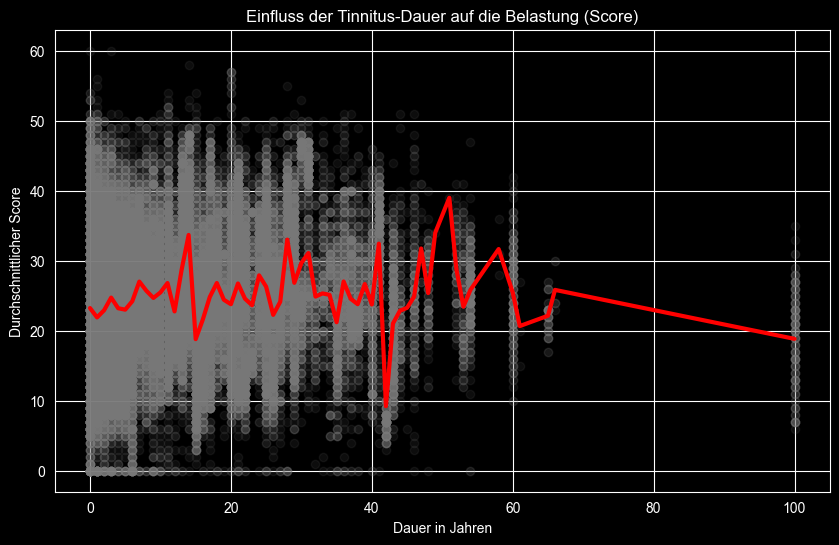

In [70]:
# jetzt wechsel von lärm hin zu onset duration

# Statistischer Zusammenhang: Dauer vs. Score
duration_effect = df.groupby('onset_duration')['score'].mean().reset_index()

plt.figure(figsize=(10,6))
plt.scatter(df['onset_duration'], df['score'], alpha=0.1, color='gray') # Rohdaten
plt.plot(duration_effect['onset_duration'], duration_effect['score'], color='red', linewidth=3) # Trend
plt.title("Einfluss der Tinnitus-Dauer auf die Belastung (Score)")
plt.xlabel("Dauer in Jahren")
plt.ylabel("Durchschnittlicher Score")
plt.show()

In [71]:
# 1. Datensatz der Lärm-Ereignisse vorbereiten
noise_events = df[df['after_noise_burst'] == True].copy()

# 2. Gruppen definieren
verlierer = noise_events[noise_events['next_delta_score'] > 0]
gewinner = noise_events[noise_events['next_delta_score'] < 0]

print(f"--- Profil-Vergleich (Lärm-Reaktion) ---")
print(f"Verlierer (N={len(verlierer)}): Mittlere Onset-Dauer = {verlierer['onset_duration'].mean():.1f} Jahre")
print(f"Gewinner  (N={len(gewinner)}): Mittlere Onset-Dauer = {gewinner['onset_duration'].mean():.1f} Jahre")

# 3. Statistischer Check: Ist der Unterschied in der Dauer signifikant?
from scipy.stats import ttest_ind
t_stat, p_val = ttest_ind(verlierer['onset_duration'].dropna(), gewinner['onset_duration'].dropna())
print(f"Signifikanz des Onset-Unterschieds: p = {p_val:.4f}")

--- Profil-Vergleich (Lärm-Reaktion) ---
Verlierer (N=4487): Mittlere Onset-Dauer = 9.4 Jahre
Gewinner  (N=4619): Mittlere Onset-Dauer = 9.8 Jahre
Signifikanz des Onset-Unterschieds: p = 0.0786


In [72]:
4487+4619

9106

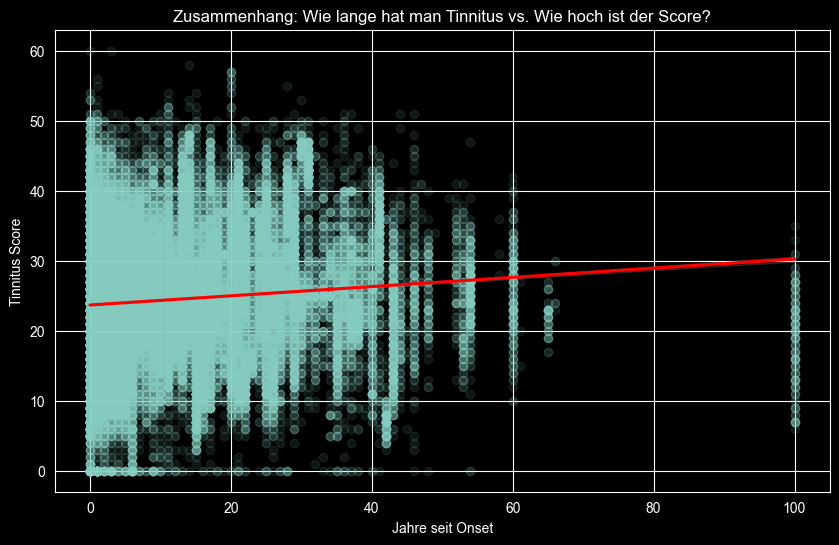

In [73]:
# Visualisierung des Trends
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='onset_duration', y='score', scatter_kws={'alpha':0.1}, line_kws={'color':'red'})
plt.title("Zusammenhang: Wie lange hat man Tinnitus vs. Wie hoch ist der Score?")
plt.xlabel("Jahre seit Onset")
plt.ylabel("Tinnitus Score")
plt.show()

In [74]:
# Wir gruppieren die Onset-Dauer in Kategorien, um den Trend zu sehen
def duration_group(days):
    if days <= 7: return "1. Woche (Akut)"
    if days <= 30: return "1. Monat (Subakut)"
    if days <= 180: return "Halbes Jahr"
    if days <= 365: return "1 Jahr"
    else: return "Chronisch (>1 Jahr)"

df['duration_cat'] = df['onset_duration'].apply(duration_group)

# Durchschnitts-Score je Dauer-Kategorie
habituation_profile = df.groupby('duration_cat')['score'].mean().sort_values(ascending=False)

print("--- Habituation: Sinkt die Belastung mit der Zeit? ---")
print(habituation_profile)

--- Habituation: Sinkt die Belastung mit der Zeit? ---
duration_cat
1. Monat (Subakut)     25.748583
Halbes Jahr            25.397034
Chronisch (>1 Jahr)    24.468293
1. Woche (Akut)        23.331854
Name: score, dtype: float64


### gemini ende